## Import

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width',1000)

## Load Data

In [140]:
holiday_events = pd.DataFrame(pd.read_csv('./store-sales-time-series-forecasting/holidays_events.csv'))
oil = pd.DataFrame(pd.read_csv('./store-sales-time-series-forecasting/oil.csv'))
stores = pd.DataFrame(pd.read_csv('./store-sales-time-series-forecasting/stores.csv'))
df_test = pd.DataFrame(pd.read_csv('./store-sales-time-series-forecasting/test.csv'))
df = pd.DataFrame(pd.read_csv('./store-sales-time-series-forecasting/train.csv'))
transactions = pd.DataFrame(pd.read_csv('./store-sales-time-series-forecasting/transactions.csv'))

## Initial Data Analysis

In [141]:
print('dtypes:')
display(pd.concat([holiday_events.dtypes,oil.dtypes,stores.dtypes,df_test.dtypes,df.dtypes,transactions.dtypes],axis=0))

print('head():')
display(pd.concat([holiday_events.head(),oil.head(),stores.head(),df_test.head(),df.head(),transactions.head()],axis=1))

print('describe():')
display(pd.concat([holiday_events.describe(),oil.describe(),stores.describe(),df_test.describe(),df.describe(),transactions.describe()],axis=1))


dtypes:


date             object
type             object
locale           object
locale_name      object
description      object
transferred        bool
date             object
dcoilwtico      float64
store_nbr         int64
city             object
state            object
type             object
cluster           int64
id                int64
date             object
store_nbr         int64
family           object
onpromotion       int64
id                int64
date             object
store_nbr         int64
family           object
sales           float64
onpromotion       int64
date             object
store_nbr         int64
transactions      int64
dtype: object

head():


,date,type,locale,locale_name,description,transferred,date,dcoilwtico,store_nbr,city,state,type,cluster,id,date,store_nbr,family,onpromotion,id,date,store_nbr,family,sales,onpromotion,date,store_nbr,transactions
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False,2013-01-01,NaN,1,Quito,Pichincha,D,13,3000888,2017-08-16,1,AUTOMOTIVE,0,0,2013-01-01,1,AUTOMOTIVE,0.00,0,2013-01-01,25,770
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False,2013-01-02,93.14,2,Quito,Pichincha,D,13,3000889,2017-08-16,1,BABY CARE,0,1,2013-01-01,1,BABY CARE,0.00,0,2013-01-02,1,2111
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False,2013-01-03,92.97,3,Quito,Pichincha,D,8,3000890,2017-08-16,1,BEAUTY,2,2,2013-01-01,1,BEAUTY,0.00,0,2013-01-02,2,2358
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False,2013-01-04,93.12,4,Quito,Pichincha,D,9,3000891,2017-08-16,1,BEVERAGES,20,3,2013-01-01,1,BEVERAGES,0.00,0,2013-01-02,3,3487
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False,2013-01-07,93.20,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4,3000892,2017-08-16,1,BOOKS,0,4,2013-01-01,1,BOOKS,0.00,0,2013-01-02,4,1922


describe():


,date,type,locale,locale_name,description,transferred,dcoilwtico,store_nbr,cluster,id,store_nbr,onpromotion,id,store_nbr,sales,onpromotion,store_nbr,transactions
count,350,350,350,350,350,350,"1,175.00",54.00,54.00,"28,512.00","28,512.00","28,512.00","3,000,888.00","3,000,888.00","3,000,888.00","3,000,888.00","83,488.00","83,488.00"
unique,312,6,3,24,103,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2014-06-25,Holiday,National,Ecuador,Carnaval,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4,221,174,174,10,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,67.71,27.50,8.48,"3,015,143.50",27.50,6.97,"1,500,443.50",27.50,357.78,2.60,26.94,"1,694.60"
std,NaN,NaN,NaN,NaN,NaN,NaN,25.63,15.73,4.69,"8,230.85",15.59,20.68,"866,281.89",15.59,"1,102.00",12.22,15.61,963.29
min,NaN,NaN,NaN,NaN,NaN,NaN,26.19,1.00,1.00,"3,000,888.00",1.00,0.00,0.00,1.00,0.00,0.00,1.00,5.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,46.41,14.25,4.00,"3,008,015.75",14.00,0.00,"750,221.75",14.00,0.00,0.00,13.00,"1,046.00"
50%,NaN,NaN,NaN,NaN,NaN,NaN,53.19,27.50,8.50,"3,015,143.50",27.50,0.00,"1,500,443.50",27.50,11.00,0.00,27.00,"1,393.00"
75%,NaN,NaN,NaN,NaN,NaN,NaN,95.66,40.75,13.00,"3,022,271.25",41.00,6.00,"2,250,665.25",41.00,195.85,0.00,40.00,"2,079.00"


## Oil

        date  dcoilwtico  date_ord
0 2013-01-01       93.11    734869
1 2013-01-02       93.14    734870
2 2013-01-03       92.97    734871
3 2013-01-04       93.12    734872
4 2013-01-07       93.20    734875


<Axes: xlabel='date', ylabel='dcoilwtico'>

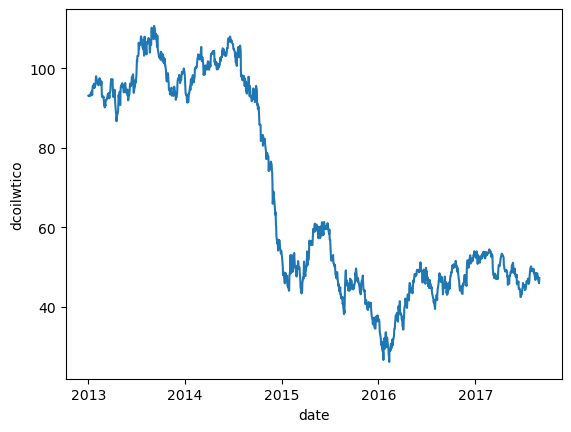

In [142]:
oil['date'] = pd.to_datetime(oil['date'])
oil['date_ord'] = oil['date'].apply(lambda x : x.toordinal())

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(oil[['dcoilwtico','date_ord']])

imputer = KNNImputer(n_neighbors=5,weights='distance')
imputed_scaled = imputer.fit_transform(scaled_features)
imputed_features = scaler.inverse_transform(imputed_scaled)

oil['dcoilwtico'] = imputed_features[:,0]
print(oil.head())
sns.lineplot(data=oil, x='date', y='dcoilwtico')

## Stores

In [143]:
display(stores.head())

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


## Transactions

In [144]:
display(transactions.head())

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


## Events and Holidays

In [145]:
display(holiday_events.head())

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


## df

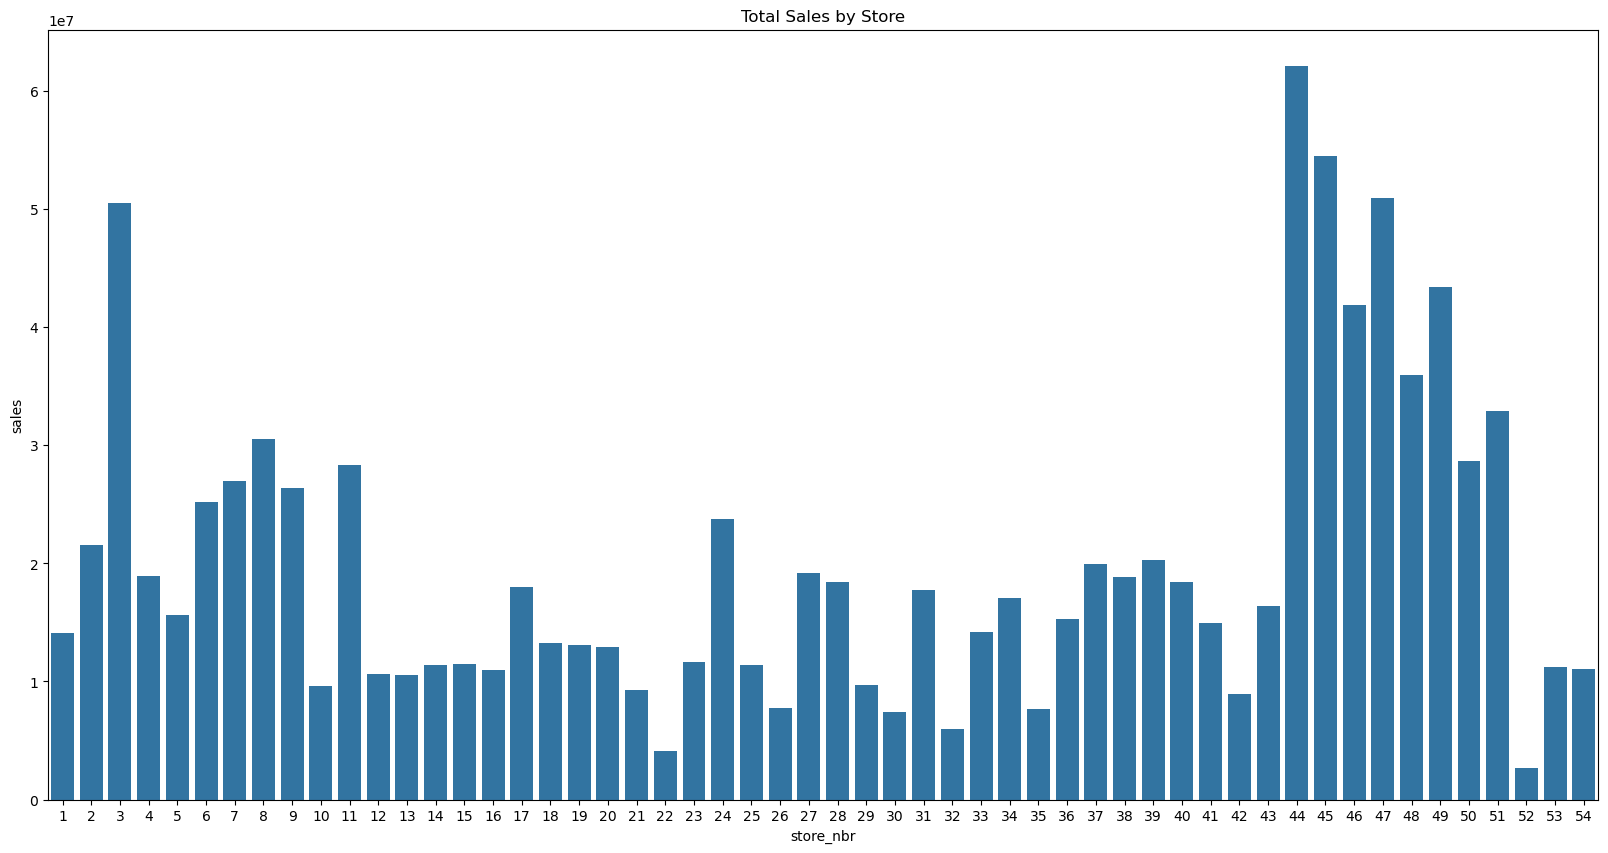

In [146]:
df = df.sort_values(by=['date','store_nbr'])

grouped_df = pd.DataFrame(df.groupby('store_nbr')['sales'].sum())
plt.figure(figsize=(20,10))
sns.barplot(data=grouped_df,x='store_nbr', y='sales')
plt.title('Total Sales by Store')

del grouped_df

#### combine train,label,transactions,oil,stores,holiday_events

In [147]:
oil['date'] = oil['date'].dt.strftime('%Y-%m-%d')

df = pd.merge(df,oil,on=['date'],how='left')
df = pd.merge(df, stores,on=['store_nbr'],how='left')
df = pd.merge(df,holiday_events,on=['date'],how='left')
df = pd.merge(df,transactions,on=['date','store_nbr'],how='left')

df.rename(columns={'type_x':'type_store','type_y':'type_holiday'},inplace=True)

display(df.head())

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,date_ord,city,state,type_store,cluster,type_holiday,locale,locale_name,description,transferred,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0,93.11,"734,869.00",Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN
1,1,2013-01-01,1,BABY CARE,0.00,0,93.11,"734,869.00",Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN
2,2,2013-01-01,1,BEAUTY,0.00,0,93.11,"734,869.00",Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN
3,3,2013-01-01,1,BEVERAGES,0.00,0,93.11,"734,869.00",Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN
4,4,2013-01-01,1,BOOKS,0.00,0,93.11,"734,869.00",Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN


## df_test

#### combine df,transactions,oil,stores,holiday_events

In [148]:
df_test = df_test.sort_values(by=['date','store_nbr'])
df_test = df_test.reset_index(drop=True)

df_test = pd.merge(df_test,oil,on=['date'],how='left')
df_test = pd.merge(df_test, stores,on=['store_nbr'],how='left')
df_test = pd.merge(df_test,holiday_events,on=['date'],how='left')
df_test = pd.merge(df_test,transactions,on=['date','store_nbr'],how='left')

df_test.rename(columns={'type_x':'type_store','type_y':'type_holiday'},inplace=True)

## Encoding

In [149]:
encoder = LabelEncoder()

for i in ['city','state','type_store','type_holiday','locale','locale_name','description','transferred']:
    df[i] = encoder.fit_transform(df[i])
    df_test[i] = encoder.transform(df_test[i])
    print(encoder.classes_)

df['family'] = encoder.fit_transform(df['family'])
df_test['family'] = encoder.transform(df_test['family'])

df['date'] = pd.to_datetime(df['date'])
df['date_ord'] = df['date'].apply(lambda x : x.toordinal())

df_test['date'] = pd.to_datetime(df_test['date'])
df_test['date_ord'] = df_test['date'].apply(lambda x : x.toordinal())

display(df.head())
display(df_test.head())

['Ambato' 'Babahoyo' 'Cayambe' 'Cuenca' 'Daule' 'El Carmen' 'Esmeraldas'
 'Guaranda' 'Guayaquil' 'Ibarra' 'Latacunga' 'Libertad' 'Loja' 'Machala'
 'Manta' 'Playas' 'Puyo' 'Quevedo' 'Quito' 'Riobamba' 'Salinas'
 'Santo Domingo']
['Azuay' 'Bolivar' 'Chimborazo' 'Cotopaxi' 'El Oro' 'Esmeraldas' 'Guayas'
 'Imbabura' 'Loja' 'Los Rios' 'Manabi' 'Pastaza' 'Pichincha' 'Santa Elena'
 'Santo Domingo de los Tsachilas' 'Tungurahua']
['A' 'B' 'C' 'D' 'E']
['Additional' 'Bridge' 'Event' 'Holiday' 'Transfer' 'Work Day' nan]
['Local' 'National' 'Regional' nan]
['Ambato' 'Cayambe' 'Cotopaxi' 'Cuenca' 'Ecuador' 'El Carmen' 'Esmeraldas'
 'Guaranda' 'Guayaquil' 'Ibarra' 'Imbabura' 'Latacunga' 'Libertad' 'Loja'
 'Machala' 'Manta' 'Puyo' 'Quevedo' 'Quito' 'Riobamba' 'Salinas'
 'Santa Elena' 'Santo Domingo' 'Santo Domingo de los Tsachilas' nan]
['Batalla de Pichincha' 'Black Friday' 'Cantonizacion de Cayambe'
 'Cantonizacion de El Carmen' 'Cantonizacion de Guaranda'
 'Cantonizacion de Latacunga' 'Cantonizaci

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,date_ord,city,state,type_store,cluster,type_holiday,locale,locale_name,description,transferred,transactions
0,0,2013-01-01,1,0,0.00,0,93.11,734869,18,12,3,13,3,1,4,50,0,NaN
1,1,2013-01-01,1,1,0.00,0,93.11,734869,18,12,3,13,3,1,4,50,0,NaN
2,2,2013-01-01,1,2,0.00,0,93.11,734869,18,12,3,13,3,1,4,50,0,NaN
3,3,2013-01-01,1,3,0.00,0,93.11,734869,18,12,3,13,3,1,4,50,0,NaN
4,4,2013-01-01,1,4,0.00,0,93.11,734869,18,12,3,13,3,1,4,50,0,NaN


,id,date,store_nbr,family,onpromotion,dcoilwtico,date_ord,city,state,type_store,cluster,type_holiday,locale,locale_name,description,transferred,transactions
0,3000888,2017-08-16,1,0,0,46.80,736557,18,12,3,13,6,3,24,101,2,NaN
1,3000889,2017-08-16,1,1,0,46.80,736557,18,12,3,13,6,3,24,101,2,NaN
2,3000890,2017-08-16,1,2,2,46.80,736557,18,12,3,13,6,3,24,101,2,NaN
3,3000891,2017-08-16,1,3,20,46.80,736557,18,12,3,13,6,3,24,101,2,NaN
4,3000892,2017-08-16,1,4,0,46.80,736557,18,12,3,13,6,3,24,101,2,NaN


## Imputation

In [150]:
scaler = MinMaxScaler()
imputer = SimpleImputer()

scaled_features = scaler.fit_transform(df[['dcoilwtico','date_ord']])
imputed_scaled = imputer.fit_transform(scaled_features)
imputed_features = scaler.inverse_transform(imputed_scaled)

df['dcoilwtico'] = imputed_features[:,0]
df['date_ord'] = imputed_features[:,1]

scaled_features = scaler.fit_transform(df_test[['dcoilwtico','date_ord']])
imputed_scaled = imputer.fit_transform(scaled_features)
imputed_features = scaler.inverse_transform(imputed_scaled)

df_test['dcoilwtico'] = imputed_features[:,0]
df_test['date_ord'] = imputed_features[:,1]

df['transactions'] = df['transactions'].fillna(0)
df_test['transactions'] = df_test['transactions'].fillna(0)

display(df.head())
display(df_test.head())

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,date_ord,city,state,type_store,cluster,type_holiday,locale,locale_name,description,transferred,transactions
0,0,2013-01-01,1,0,0.00,0,93.11,"734,869.00",18,12,3,13,3,1,4,50,0,0.00
1,1,2013-01-01,1,1,0.00,0,93.11,"734,869.00",18,12,3,13,3,1,4,50,0,0.00
2,2,2013-01-01,1,2,0.00,0,93.11,"734,869.00",18,12,3,13,3,1,4,50,0,0.00
3,3,2013-01-01,1,3,0.00,0,93.11,"734,869.00",18,12,3,13,3,1,4,50,0,0.00
4,4,2013-01-01,1,4,0.00,0,93.11,"734,869.00",18,12,3,13,3,1,4,50,0,0.00


,id,date,store_nbr,family,onpromotion,dcoilwtico,date_ord,city,state,type_store,cluster,type_holiday,locale,locale_name,description,transferred,transactions
0,3000888,2017-08-16,1,0,0,46.80,"736,557.00",18,12,3,13,6,3,24,101,2,0.00
1,3000889,2017-08-16,1,1,0,46.80,"736,557.00",18,12,3,13,6,3,24,101,2,0.00
2,3000890,2017-08-16,1,2,2,46.80,"736,557.00",18,12,3,13,6,3,24,101,2,0.00
3,3000891,2017-08-16,1,3,20,46.80,"736,557.00",18,12,3,13,6,3,24,101,2,0.00
4,3000892,2017-08-16,1,4,0,46.80,"736,557.00",18,12,3,13,6,3,24,101,2,0.00


## Scaling

In [151]:
display(df.describe())

scaler = MinMaxScaler((0,100))
columns_to_scale = ['date_ord','dcoilwtico']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
df_test[columns_to_scale] = scaler.transform(df_test[columns_to_scale])
df['transactions'] = df['transactions']/33
df_test['transactions'] = df_test['transactions']/33

display(df.describe())

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,date_ord,city,state,type_store,cluster,type_holiday,locale,locale_name,description,transferred,transactions
count,"3,054,348.00",3054348,"3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00"
mean,"1,504,276.78",2015-04-26 12:11:45.717619200,27.50,16.00,359.02,2.62,67.94,"735,714.51",12.56,8.80,2.00,8.48,5.41,2.61,21.29,90.26,1.68,"1,558.66"
min,0.00,2013-01-01 00:00:00,1.00,0.00,0.00,0.00,26.19,"734,869.00",0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"754,676.75",2014-03-01 00:00:00,14.00,8.00,0.00,0.00,48.86,"735,293.00",8.00,6.00,1.00,4.00,6.00,3.00,24.00,101.00,2.00,931.00
50%,"1,507,571.50",2015-04-28 12:00:00,27.50,16.00,11.00,0.00,67.94,"735,716.50",14.00,10.00,2.00,8.50,6.00,3.00,24.00,101.00,2.00,"1,332.00"
75%,"2,255,120.25",2016-06-22 00:00:00,41.00,24.00,196.01,0.00,92.46,"736,137.00",18.00,12.00,3.00,13.00,6.00,3.00,24.00,101.00,2.00,"1,980.00"
max,"3,000,887.00",2017-08-15 00:00:00,54.00,32.00,"124,717.00",741.00,110.62,"736,556.00",21.00,15.00,4.00,17.00,6.00,3.00,24.00,101.00,2.00,"8,359.00"
std,"866,261.01",NaN,15.59,9.52,"1,107.29",12.25,21.67,487.43,6.26,4.17,1.20,4.65,1.39,0.90,6.57,26.54,0.73,"1,036.47"


,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,date_ord,city,state,type_store,cluster,type_holiday,locale,locale_name,description,transferred,transactions
count,"3,054,348.00",3054348,"3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00","3,054,348.00"
mean,"1,504,276.78",2015-04-26 12:11:45.717619200,27.50,16.00,359.02,2.62,49.45,50.12,12.56,8.80,2.00,8.48,5.41,2.61,21.29,90.26,1.68,47.23
min,0.00,2013-01-01 00:00:00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"754,676.75",2014-03-01 00:00:00,14.00,8.00,0.00,0.00,26.85,25.13,8.00,6.00,1.00,4.00,6.00,3.00,24.00,101.00,2.00,28.21
50%,"1,507,571.50",2015-04-28 12:00:00,27.50,16.00,11.00,0.00,49.45,50.24,14.00,10.00,2.00,8.50,6.00,3.00,24.00,101.00,2.00,40.36
75%,"2,255,120.25",2016-06-22 00:00:00,41.00,24.00,196.01,0.00,78.49,75.16,18.00,12.00,3.00,13.00,6.00,3.00,24.00,101.00,2.00,60.00
max,"3,000,887.00",2017-08-15 00:00:00,54.00,32.00,"124,717.00",741.00,100.00,100.00,21.00,15.00,4.00,17.00,6.00,3.00,24.00,101.00,2.00,253.30
std,"866,261.01",NaN,15.59,9.52,"1,107.29",12.25,25.66,28.89,6.26,4.17,1.20,4.65,1.39,0.90,6.57,26.54,0.73,31.41


## Multi-Layer Perceptron Regressor

In [152]:
print(df.columns.to_list())

mlpr = MLPRegressor(
    hidden_layer_sizes=(64,32,16),
    learning_rate='adaptive',
    random_state = 42,
    max_iter= 20,
    verbose=True
)

mlpr.fit(df.drop(columns=['id','sales','date']),df['sales'])

['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'dcoilwtico', 'date_ord', 'city', 'state', 'type_store', 'cluster', 'type_holiday', 'locale', 'locale_name', 'description', 'transferred', 'transactions']
Iteration 1, loss = 373697.99012295
Iteration 2, loss = 330949.98310565
Iteration 3, loss = 271264.75112715
Iteration 4, loss = 203868.87153043
Iteration 5, loss = 173285.69743308
Iteration 6, loss = 158407.47872923
Iteration 7, loss = 151410.66297164
Iteration 8, loss = 146364.02399012
Iteration 9, loss = 141965.48236308
Iteration 10, loss = 138146.93362834
Iteration 11, loss = 134852.81300543
Iteration 12, loss = 132464.42070017
Iteration 13, loss = 129557.00265143
Iteration 14, loss = 124287.10804289
Iteration 15, loss = 117400.72771271
Iteration 16, loss = 112087.88634435
Iteration 17, loss = 111158.53311038
Iteration 18, loss = 113400.90179163
Iteration 19, loss = 122853.56907026
Iteration 20, loss = 120983.80218496


/home/anshul/Documents/anaconda3/envs/kaggle/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32, 16), learning_rate='adaptive',
             max_iter=20, random_state=42, verbose=True)

## prediction writing

In [153]:
prediction = pd.DataFrame({
    'id': df_test['id'],
    'sales': mlpr.predict(df_test.drop(columns=['id', 'date']))
})

prediction.to_csv('submission.csv',index=False)